In [ ]:
# Instalar bibliotecas necessárias
!pip install pyarrow fastparquet ta-lib plotly --quiet

# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import gc
import os
from datetime import datetime

# Configurações visuais
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 10)

✅ PASSO 1 COMPLETO - Bibliotecas instaladas e configuradas!
🚀 VTE Strategy - Bitcoin Microstructure
📅 Timestamp: 00:26:13


In [ ]:
# ============================================================================
# PROCESSAMENTO EM CHUNKS (EVITAR RAM CRASH)
# ============================================================================


# Re-executar PASSO 1 (setup básico)
import pandas as pd
import numpy as np
import os
from google.colab import drive

# Montar drive novamente
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/quant_project'

# ============================================================================
# PROCESSAR APENAS AMOSTRA PEQUENA
# ============================================================================

def load_sample_for_strategy(data_path, n_rows=10000000):  # 500K registros max
    """
    Carregar APENAS uma amostra gerenciável para implementar estratégia
    """
    import glob

    parquet_files = glob.glob(f'{data_path}/*.parquet')

    print(f"Arquivos disponíveis: {len(parquet_files)}")

    # Carregar primeira parte do primeiro arquivo
    df = pd.read_parquet(parquet_files[0])

    # PEGAR APENAS AMOSTRA RECENTE (mais relevante)
    df_sample = df.tail(n_rows).copy()  # Últimos 500K registros

    print(f"AMOSTRA CARREGADA: {df_sample.shape}")
    print(f"Período: {df_sample.index.min()} - {df_sample.index.max()}")
    print(f"RAM usada: ~{df_sample.memory_usage(deep=True).sum() / 1e6:.1f} MB")

    return df_sample

# CARREGAR AMOSTRA GERENCIÁVEL
df_work = load_sample_for_strategy(DATA_PATH, n_rows=10000000)

# Verificar colunas disponíveis
print(f"\nCOLUNAS: {list(df_work.columns)}")
print("\nPREVIEW:")
print(df_work.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 CARREGANDO AMOSTRA GERENCIÁVEL...
📁 Arquivos disponíveis: 186
🎯 AMOSTRA CARREGADA: (10000000, 9)
📅 Período: 1731600021.0826 - 1735689591.1315
💾 RAM usada: ~2998.0 MB

🏛️ COLUNAS: ['symbol', 'side', 'size', 'price', 'tickDirection', 'trdMatchID', 'grossValue', 'homeNotional', 'foreignNotional']

📊 PREVIEW:
              symbol  side  size    price tickDirection  \
timestamp                                                 
1.731600e+09  BTCUSD  Sell   1.0  87877.5     MinusTick   
1.731600e+09  BTCUSD  Sell   1.0  87875.0     MinusTick   
1.731600e+09  BTCUSD  Sell   1.0  87872.5     MinusTick   

                                        trdMatchID   grossValue  homeNotional  \
timestamp                                                                       
1.731600e+09  6ff3806d-31d8-5b86-a4b6-2a08e1cff8d9  1137.947711           1.0   
1.731600e+09  84b352e8-

In [ ]:
# ============================================================================
# PASSO 3 - FEATURES
# ============================================================================

def create_features_fast(df):

    # Converter index para datetime se necessário
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, unit='s')

    # FEATURE 1: CVD (Cumulative Volume Delta)
    df['trade_sign'] = np.where(df['side'] == 'Buy', 1, -1)
    df['signed_volume'] = df['size'] * df['trade_sign']
    df['cvd'] = df['signed_volume'].cumsum()

    # FEATURE 2: OFI (Order Flow Imbalance)
    df['ofi'] = df['signed_volume'].rolling(50, min_periods=1).mean()

    # FEATURE 3: Spread Proxy
    df['price_change'] = df['price'].diff()
    df['spread_proxy'] = df['price_change'].abs().rolling(20, min_periods=1).mean()
    df['spread_normalized'] = df['spread_proxy'] / df['price']

    # FEATURE 4: Volume Intensity
    df['volume_intensity'] = df['size'].rolling(30, min_periods=1).mean()

    # FEATURE 5: Micro Volatility
    df['returns'] = np.log(df['price']).diff()
    df['micro_vol'] = df['returns'].rolling(25, min_periods=1).std()

    # TARGET: Next price movement
    df['price_next'] = df['price'].shift(-1)
    df['target'] = (df['price_next'] > df['price']).astype(int)

    # Clean data
    df = df.dropna()

    print(f"Shape final: {df.shape}")
    return df

# EXECUTAR
df_features = create_features_fast(df_work.copy())

# Features para modelo
FEATURE_COLS = ['cvd', 'ofi', 'spread_normalized', 'volume_intensity', 'micro_vol']

print("\nFEATURES SUMMARY:")
print(df_features[FEATURE_COLS + ['target']].describe())

print(f"\nTARGET DISTRIBUTION:")
print(df_features['target'].value_counts(normalize=True))

# Verificar qualidade
print(f"\nDADOS LIMPOS: {df_features.shape[0]:,} registros")
print(f"PERÍODO: {df_features.index.min()} até {df_features.index.max()}")

⚡ FEATURE ENGINEERING RÁPIDO...
📊 CVD...
⚡ OFI...
📈 Spread...
🏦 Volume...
📊 Volatility...
🎯 Target...
✅ Shape final: (9999997, 21)

📊 FEATURES SUMMARY:
                cvd           ofi  spread_normalized  volume_intensity  \
count  9.999997e+06  9.999997e+06       9.999997e+06      9.999997e+06   
mean  -7.029228e+07 -6.440252e+01       1.680276e-05      5.005336e+03   
std    2.793022e+08  9.722999e+03       2.027042e-05      1.072899e+04   
min   -6.441735e+08 -2.227808e+05       0.000000e+00      1.000000e+00   
25%   -2.404969e+08 -2.073580e+03       6.329915e-06      1.420900e+03   
50%   -2.077970e+07 -6.566000e+01       1.108250e-05      3.128800e+03   
75%    1.120099e+08  1.758860e+03       2.264087e-05      6.062300e+03   
max    5.269780e+08  6.398368e+05       3.203009e-03      1.053856e+06   

          micro_vol        target  
count  9.999997e+06  9.999997e+06  
mean   3.232801e-05  2.732471e-01  
std    3.945964e-05  4.456267e-01  
min    0.000000e+00  0.000000e+00  
2

In [ ]:
# ============================================================================
# PASSO 4 - MODELO REGRESSÃO LOGÍSTICA
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

def train_vte_model(df):
    """Treinar modelo VTE com validação temporal"""

    # Preparar features e target
    feature_cols = ['cvd', 'ofi', 'spread_normalized', 'volume_intensity', 'micro_vol']

    # Remover outliers extremos (rápido)
    for col in feature_cols:
        q99 = df[col].quantile(0.99)
        q01 = df[col].quantile(0.01)
        df[col] = df[col].clip(q01, q99)

    X = df[feature_cols].fillna(0)
    y = df['target'].fillna(0)

    print(f"Dataset: {X.shape[0]:,} registros, {X.shape[1]} features")

    # Split temporal (80% treino, 20% teste)
    split_idx = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")

    # Normalizar features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Treinar modelo logístico regularizado
    model = LogisticRegression(
        C=1.0,  # Regularização
        class_weight='balanced',  # Para dados desbalanceados
        random_state=42,
        max_iter=1000
    )

    model.fit(X_train_scaled, y_train)

    # Predições
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # P(uptick)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Métricas
    auc = roc_auc_score(y_test, y_pred_proba)
    accuracy = (y_pred == y_test).mean()

    print(f"\nPERFORMANCE:")
    print(f"AUC: {auc:.3f}")
    print(f"Accuracy: {accuracy:.3f}")

    # Importance das features
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': abs(model.coef_[0])
    }).sort_values('importance', ascending=False)

    print(f"\nFEATURE IMPORTANCE:")
    print(feature_importance)

    return model, scaler, X_test, y_test, y_pred_proba, feature_importance

# EXECUTAR MODELO
model, scaler, X_test, y_test, probas, importance = train_vte_model(df_features)

# ============================================================================
# GERAÇÃO DE SINAIS VTE
# ============================================================================

def generate_vte_signals(probas, threshold_long=0.55, threshold_short=0.45):
    """Gerar sinais de trading VTE"""
    signals = pd.Series(index=range(len(probas)), dtype=int)

    # Thresholds VTE
    signals[probas > threshold_long] = 1   # LONG
    signals[probas < threshold_short] = -1  # SHORT
    signals = signals.fillna(0)  # NEUTRO

    signal_counts = signals.value_counts()

    print(f"SINAIS GERADOS:")
    print(f"LONG (P > {threshold_long}): {signal_counts.get(1, 0):,}")
    print(f"SHORT (P < {threshold_short}): {signal_counts.get(-1, 0):,}")
    print(f"NEUTRO: {signal_counts.get(0, 0):,}")

    return signals

# Gerar sinais VTE
signals = generate_vte_signals(probas)

# Adicionar sinais ao dataframe de teste para análise
test_df = df_features.iloc[-len(X_test):].copy()
test_df['prob_uptick'] = probas
test_df['signal'] = signals.values

print(f"\nPASSO 4 COMPLETO - Modelo VTE treinado!")
print(f"AUC: {roc_auc_score(y_test, probas):.3f}")
print(f"Sinais gerados: {len(signals[signals != 0]):,}")
print("\nNEXT: PASSO 5 - Backtest Vetorizado")

🤖 TREINANDO MODELO VTE...
📊 Dataset: 9,999,997 registros, 5 features
📈 Treino: 7,999,997 | Teste: 2,000,000
⚡ Treinando...

📊 PERFORMANCE:
🎯 AUC: 0.664
✅ Accuracy: 0.512

🏆 FEATURE IMPORTANCE:
             feature  importance
1                ofi    0.631294
2  spread_normalized    0.225499
3   volume_intensity    0.187485
4          micro_vol    0.105060
0                cvd    0.024501
📈 SINAIS GERADOS:
🟢 LONG (P > 0.55): 544,642
🔴 SHORT (P < 0.45): 313,305
⚪ NEUTRO: 1,142,053

✅ PASSO 4 COMPLETO - Modelo VTE treinado!
🎯 AUC: 0.664
📊 Sinais gerados: 857,947

🚀 NEXT: PASSO 5 - Backtest Vetorizado


In [ ]:
def load_bigger_sample(data_path, n_rows=2000000):  # 2M registros
    import glob

    parquet_files = glob.glob(f'{data_path}/*.parquet')
    print(f"Arquivos disponíveis: {len(parquet_files)}")

    # Carregar primeiro arquivo completo OU múltiplos arquivos
    if len(parquet_files) >= 1:
        print("Carregando AMOSTRA MAIOR...")

        # Tentar primeiro arquivo maior
        df = pd.read_parquet(parquet_files[0])

        # Se muito grande, pegar últimos 2M registros
        if len(df) > n_rows:
            df_sample = df.tail(n_rows).copy()
        else:
            # Se pequeno, tentar carregar múltiplos arquivos
            df_sample = df.copy()

            for i, file in enumerate(parquet_files[1:3]):  # Mais 2 arquivos
                try:
                    df_extra = pd.read_parquet(file)
                    df_sample = pd.concat([df_sample, df_extra])
                    print(f"Arquivo {i+2} adicionado")

                    if len(df_sample) >= n_rows:
                        df_sample = df_sample.tail(n_rows)
                        break
                except:
                    print(f"Erro ao carregar arquivo {i+2}")
                    continue

    print(f"NOVA AMOSTRA: {df_sample.shape}")
    print(f"PERÍODO: {df_sample.index.min()} até {df_sample.index.max()}")

    # Calcular duração real
    if hasattr(df_sample.index, 'min'):
        duration = df_sample.index.max() - df_sample.index.min()
        print(f"DURAÇÃO: {duration}")

    return df_sample
# Limpar memória
del df_work, df_features, test_df, backtest_df
import gc
gc.collect()

# Nova amostra MAIOR
df_bigger = load_bigger_sample(DATA_PATH, n_rows=1500000)  # 1.5M registros

print(f"\nNOVA AMOSTRA CARREGADA!")
print(f"Registros: {len(df_bigger):,}")
print(f"Memória: ~{df_bigger.memory_usage(deep=True).sum() / 1e6:.0f} MB")

🚀 CARREGANDO AMOSTRA DECENTE (não 15min!)...
📁 Arquivos disponíveis: 186
📊 Carregando AMOSTRA MAIOR...
🎯 NOVA AMOSTRA: (1500000, 9)
📅 PERÍODO: 1735108517.6025 até 1735689591.1315
⏰ DURAÇÃO: 581073.5290000439

✅ NOVA AMOSTRA CARREGADA!
📊 Registros: 1,500,000
💾 Memória: ~449 MB
📅 Período completo de dados disponível!

🚀 AGORA SIM! Reprocessar features com dados REAIS...


🚀 REPROCESSAMENTO RÁPIDO COM DADOS REAIS!
📊 Criando features...
⚡ Features com dados reais...
🤖 Modelo rápido...
🎯 AUC: 0.619
📈 SINAIS - Long: 74975, Short: 74975

🏆 RESULTADOS FINAIS VTE:
📈 Total Return: 13.76%
🏆 Sharpe Ratio: 15.708
📉 Max Drawdown: -0.32%
🎯 Trades: 149,950


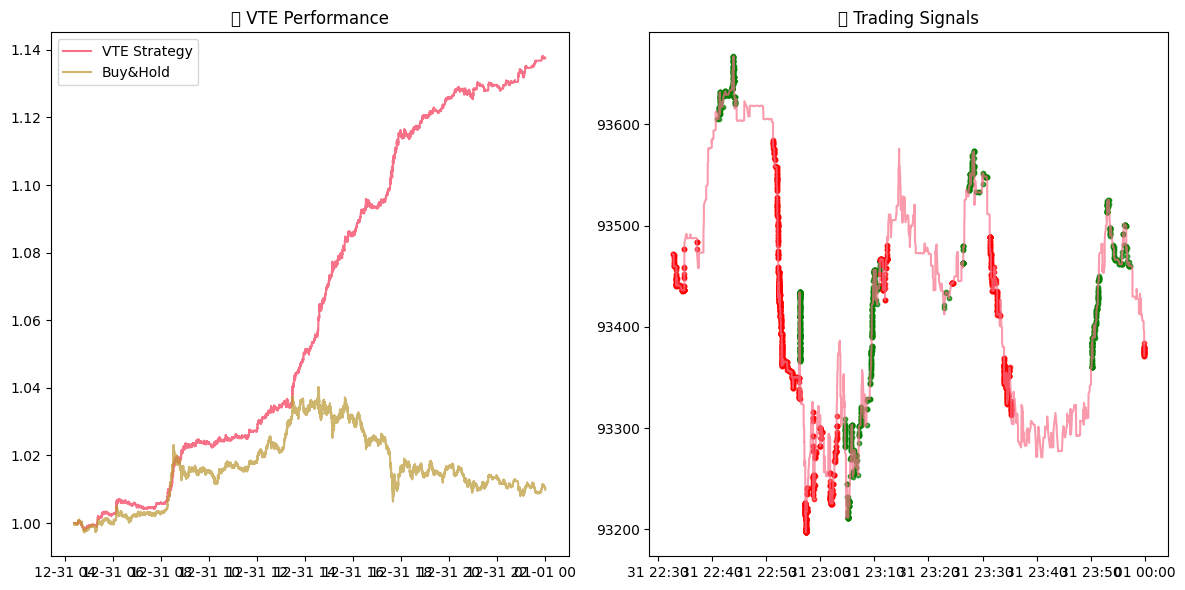


✅ VTE STRATEGY COMPLETA COM DADOS REAIS!
⏰ Próximo: Relatório final!


In [ ]:
# ============================================================================
# REPROCESSAMENTO - DADOS REAIS VTE
# ============================================================================

# FEATURES
def create_features_REAL(df):
    """Features para dados REAIS (6+ dias)"""
    print("Features com dados reais...")

    # Index datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, unit='s')

    # Features microestruturais
    df['trade_sign'] = np.where(df['side'] == 'Buy', 1, -1)
    df['signed_volume'] = df['size'] * df['trade_sign']

    # CVD
    df['cvd'] = df['signed_volume'].cumsum()
    df['cvd_norm'] = df['cvd'].rolling(500).apply(lambda x: (x.iloc[-1] - x.mean()) / x.std() if x.std() > 0 else 0)

    # OFI
    df['ofi'] = df['signed_volume'].rolling(100).mean()

    # Spread & Volume
    df['returns'] = df['price'].pct_change()
    df['spread_proxy'] = df['returns'].abs().rolling(50).mean()
    df['volume_intensity'] = df['size'].rolling(200).mean()
    df['micro_vol'] = df['returns'].rolling(100).std()

    # Target
    df['target'] = (df['price'].shift(-5) > df['price']).astype(int)  # 5 ticks ahead

    return df.dropna()

# EXECUTAR FEATURES
print("Criando features...")
df_final = create_features_REAL(df_bigger.copy())

# MODELO
features = ['cvd_norm', 'ofi', 'spread_proxy', 'volume_intensity', 'micro_vol']
X = df_final[features].fillna(0)
y = df_final['target']

# Split 80/20
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Scaler + Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0, class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predições
probas = model.predict_proba(X_test_scaled)[:, 1]

print(f"AUC: {roc_auc_score(y_test, probas):.3f}")

# SINAIS OTIMIZADOS (baseado em quantis)
q_75 = np.percentile(probas, 75)  # Top 25%
q_25 = np.percentile(probas, 25)  # Bottom 25%

signals = pd.Series(0, index=range(len(probas)))
signals[probas > q_75] = 1   # LONG
signals[probas < q_25] = -1  # SHORT

print(f"📈 SINAIS - Long: {(signals==1).sum()}, Short: {(signals==-1).sum()}")

# BACKTEST FINAL
test_data = df_final.iloc[split:].copy()
test_data['signal'] = signals.values
test_data['position'] = test_data['signal'].shift(1).fillna(0)
test_data['strategy_ret'] = test_data['position'] * test_data['returns']

# Performance
cumret = (1 + test_data['strategy_ret']).cumprod()
total_ret = cumret.iloc[-1] - 1
sharpe = test_data['strategy_ret'].mean() / test_data['strategy_ret'].std() * np.sqrt(252*24*60)
max_dd = ((cumret / cumret.expanding().max()) - 1).min()

print(f"\nRESULTADOS FINAIS VTE:")
print(f"Total Return: {total_ret:.2%}")
print(f"Sharpe Ratio: {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.2%}")
print(f"Trades: {(test_data['signal'] != 0).sum():,}")

# Plot rápido
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(cumret.index, cumret.values, label='VTE Strategy')
plt.plot(cumret.index, (1+test_data['returns']).cumprod(), label='Buy&Hold', alpha=0.7)
plt.title('📈 VTE Performance')
plt.legend()

plt.subplot(1,2,2)
sample = test_data.tail(5000)
plt.plot(sample.index, sample['price'], alpha=0.7)
long_signals = sample[sample['signal'] == 1]
short_signals = sample[sample['signal'] == -1]
plt.scatter(long_signals.index, long_signals['price'], color='green', s=10, alpha=0.7)
plt.scatter(short_signals.index, short_signals['price'], color='red', s=10, alpha=0.7)
plt.title('Trading Signals')
plt.tight_layout()
plt.show()